In [1]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
articles = pd.read_csv("../Data/articles.csv")

transactions = pd.read_csv(
    "../Data/transactions_train.csv",
    nrows=200000
)

transactions["t_dat"] = pd.to_datetime(
    transactions["t_dat"]
)

In [3]:
# Loading Similarity Matrix

with open("../models/similarity.pkl", "rb") as f:
    similarity_df = pickle.load(f)

In [4]:
similarity_df.shape

(3032, 3032)

In [5]:
transactions = transactions.sort_values("t_dat")

train_data = (
    transactions
    .groupby("customer_id")
    .head(-1)
)

test_data = (
    transactions
    .groupby("customer_id")
    .tail(1)
)

In [6]:
print(train_data.shape)
print(test_data.shape)

(148473, 5)
(51527, 5)


In [7]:
# Recommending Function

def recommend_products(article_id, top_n=10):

    if article_id not in similarity_df.columns:
        return []

    recommendations = (
        similarity_df[article_id]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .index
        .tolist()
    )

    return recommendations

In [8]:
# Precision@K

def precision_at_k(test_data, k=10):

    precision_scores = []

    for customer in test_data["customer_id"]:

        actual_items = test_data[
            test_data["customer_id"] == customer
        ]["article_id"].tolist()

        train_items = train_data[
            train_data["customer_id"] == customer
        ]["article_id"].tolist()

        if len(train_items) == 0:
            continue

        seed_item = train_items[-1]

        recommendations = recommend_products(
            seed_item,
            k
        )

        hits = len(
            set(actual_items) &
            set(recommendations)
        )

        precision_scores.append(
            hits / k
        )

    return np.mean(precision_scores)

In [9]:
precision = precision_at_k(
    test_data,
    k=10
)

print(
    f"Precision@10: {precision:.4f}"
)

Precision@10: 0.0071


In [10]:
# Recall@K

def recall_at_k(test_data, k=10):

    recall_scores = []

    for customer in test_data["customer_id"]:

        actual_items = test_data[
            test_data["customer_id"] == customer
        ]["article_id"].tolist()

        train_items = train_data[
            train_data["customer_id"] == customer
        ]["article_id"].tolist()

        if len(train_items) == 0:
            continue

        seed_item = train_items[-1]

        recommendations = recommend_products(
            seed_item,
            k
        )

        hits = len(
            set(actual_items) &
            set(recommendations)
        )

        recall_scores.append(
            hits / len(actual_items)
        )

    return np.mean(recall_scores)

In [11]:
recall = recall_at_k(
    test_data,
    k=10
)

print(
    f"Recall@10: {recall:.4f}"
)

Recall@10: 0.0705


In [12]:
# Hit Rate

def hit_rate(test_data, k=10):

    hits = 0
    total = 0

    for customer in test_data["customer_id"]:

        actual_items = test_data[
            test_data["customer_id"] == customer
        ]["article_id"].tolist()

        train_items = train_data[
            train_data["customer_id"] == customer
        ]["article_id"].tolist()

        if len(train_items) == 0:
            continue

        seed_item = train_items[-1]

        recommendations = recommend_products(
            seed_item,
            k
        )

        if len(
            set(actual_items)
            &
            set(recommendations)
        ) > 0:

            hits += 1

        total += 1

    return hits / total

In [13]:
hr = hit_rate(
    test_data,
    k=10
)

print(
    f"Hit Rate: {hr:.4f}"
)

Hit Rate: 0.0705


In [14]:
# Visualization

metrics = pd.DataFrame({

    "Metric":[
        "Precision@10",
        "Recall@10",
        "Hit Rate"
    ],

    "Score":[
        precision,
        recall,
        hr
    ]
})

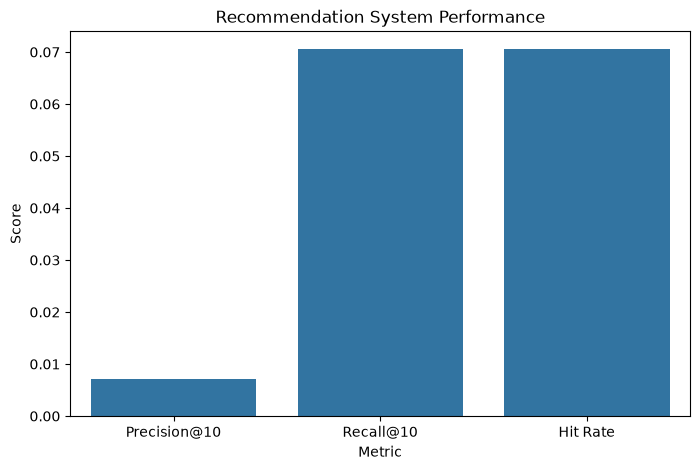

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=metrics,
    x="Metric",
    y="Score"
)

plt.title(
    "Recommendation System Performance"
)

plt.show()

In [16]:
# Recommendation Examples

article_lookup = (
    articles
    .set_index("article_id")
    ["prod_name"]
    .to_dict()
)

In [17]:
sample_product = (
    transactions["article_id"]
    .iloc[0]
)

In [18]:
recommendations = recommend_products(
    sample_product,
    top_n=5
)

In [19]:
# Display

print(
    "Selected Product:"
)

print(
    article_lookup.get(
        sample_product
    )
)

print("\nRecommendations:\n")

for item in recommendations:

    print(
        article_lookup.get(item)
    )

Selected Product:
Atlanta Push Body Harlow

Recommendations:

Hazelnut push body
Charlotte hipster
Charlotte Body Push Melbourne
Eden lotus bikini
Eden lotus bikini
